In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

In [2]:
# 1. 再現性のためのシード設定
np.random.seed(42)

# 2. データ生成数
n_samples = 1000

# 3. ダミーデータの生成
# 交絡因子 Z: 気温 (標準化済み: 0を平均とした変動)
# 低いほど寒く、高いほど暑い
temperature = np.random.normal(0, 1, n_samples)

In [3]:
# 原因変数 X: 風速
# 設定: 気温が低いほど、風が強い (負の相関) + ランダムなノイズ
# 風速 = -0.7 * 気温 + ノイズ
wind_speed = -0.7 * temperature + np.random.normal(0, 0.5, n_samples)
# 負の値を防ぐための補正（絶対値やシフト）も可能ですが、今回は簡易モデルとしてこのまま扱います

# 結果変数 Y: 桶屋の売上
# 設定: 気温が低いほど、乾燥して桶が売れる (負の相関) + ランダムなノイズ
# ★重要: ここに `wind_speed` を含めないことで「直接の因果はない」状態を作ります
barrel_sales = -0.8 * temperature + np.random.normal(0, 0.5, n_samples)

# DataFrameにまとめる
df = pd.DataFrame({
    'Temperature': temperature,
    'Wind_Speed': wind_speed,
    'Barrel_Sales': barrel_sales
})

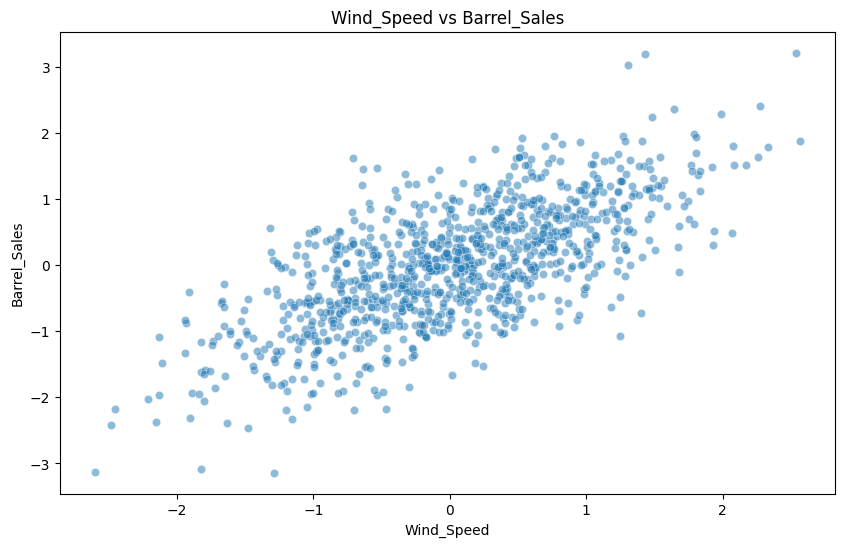

風速と売上の単純相関係数: 0.686


In [4]:
# --- 解析フェーズ ---

# 4. 単純な散布図と相関の確認（可視化）
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Wind_Speed', y='Barrel_Sales', data=df, alpha=0.5)
plt.title('Wind_Speed vs Barrel_Sales')
plt.xlabel('Wind_Speed')
plt.ylabel('Barrel_Sales')
plt.show()

# 相関係数の算出
corr = df[['Wind_Speed', 'Barrel_Sales']].corr().iloc[0, 1]
print(f"風速と売上の単純相関係数: {corr:.3f}")

In [5]:
# 5. 回帰分析による検証

print("\n--- Model 1: 単回帰分析 (売上 ~ 風速) ---")
# 誤った結論を導くモデル（交絡因子を無視）
X1 = sm.add_constant(df['Wind_Speed'])
y = df['Barrel_Sales']
model1 = sm.OLS(y, X1).fit()
print(model1.summary().tables[1])
# 結果予想: 風速の係数(coef)は「正の値」で「有意(P<0.05)」になるはず -> 「風が吹けば儲かる」に見える

print("\n--- Model 2: 重回帰分析 (売上 ~ 風速 + 気温) ---")
# 交絡因子を調整したモデル
X2 = sm.add_constant(df[['Wind_Speed', 'Temperature']])
model2 = sm.OLS(y, X2).fit()
print(model2.summary().tables[1])
# 結果予想: 気温を入れると、風速の係数は「ほぼ0」になり、「有意ではなくなる(P>0.05)」はず


--- Model 1: 単回帰分析 (売上 ~ 風速) ---
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0285      0.021     -1.350      0.177      -0.070       0.013
Wind_Speed     0.7271      0.024     29.779      0.000       0.679       0.775

--- Model 2: 重回帰分析 (売上 ~ 風速 + 気温) ---
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const           0.0031      0.016      0.197      0.844      -0.028       0.034
Wind_Speed     -0.0102      0.031     -0.326      0.745      -0.071       0.051
Temperature    -0.7962      0.028    -28.890      0.000      -0.850      -0.742


In [6]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from pgmpy.estimators import HillClimbSearch, BicScore

  0%|          | 0/1000000 [00:00<?, ?it/s]

学習されたエッジ: [('Temperature', 'Wind_Speed'), ('Barrel_Sales', 'Temperature')]


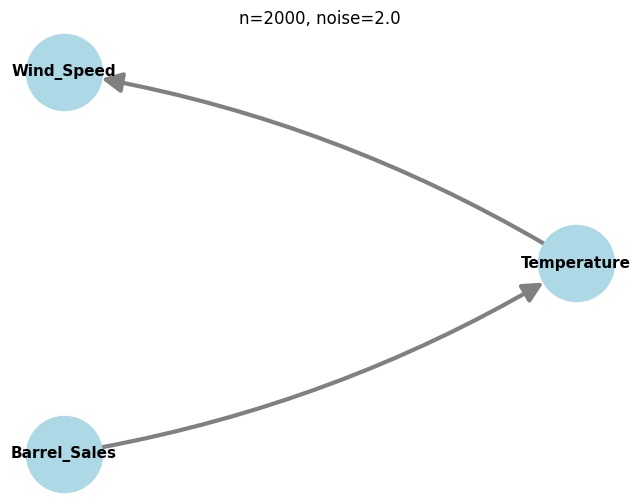

In [7]:
# 1. データ生成 (n=2000, noise=2.0)
np.random.seed(42)
n_samples = 2000
temperature = np.random.normal(0, 1, n_samples)
wind_speed = -0.7 * temperature + np.random.normal(0, 2.0, n_samples)
barrel_sales = -0.8 * temperature + np.random.normal(0, 2.0, n_samples)

df = pd.DataFrame({
    'Temperature': temperature,
    'Wind_Speed': wind_speed,
    'Barrel_Sales': barrel_sales
})

# 2. 離散化 (bins=5)
df_discrete = pd.DataFrame()
for col in df.columns:
    df_discrete[col] = pd.cut(df[col], bins=5, labels=False)

# 3. 構造学習
hc = HillClimbSearch(df_discrete)
best_model = hc.estimate(scoring_method=BicScore(df_discrete))

# 4. 可視化（矢印強調バージョン）
print("学習されたエッジ:", best_model.edges())

G = nx.DiGraph()
G.add_nodes_from(df.columns)
G.add_edges_from(best_model.edges())

plt.figure(figsize=(8, 6))
pos = nx.circular_layout(G)

# --- 描画設定の調整 ---

# ノードを描画
nx.draw_networkx_nodes(G, pos, node_size=3000, node_color='lightblue')
# ラベルを描画
nx.draw_networkx_labels(G, pos, font_size=11, font_family='sans-serif', font_weight='bold')

# エッジ（矢印）を描画
# arrowsize=30: 矢印の頭を大きくする
# node_size=3000: ノードの大きさを指定（矢印が隠れないように位置計算に使われる）
# connectionstyle='arc3, rad=0.1': 少しカーブさせて矢印を見やすくする（好みで）
nx.draw_networkx_edges(G, pos, 
                       edge_color='gray', 
                       arrows=True, 
                       arrowsize=30,      
                       arrowstyle='-|>',  
                       width=3,           
                       node_size=3000,    
                       connectionstyle='arc3, rad=0.1' 
                      )

plt.title("n=2000, noise=2.0")
plt.axis('off')
plt.show()